# 03_train — Variants A / B / C

**Kernel: `PocketBirdNET (.venv)` — CPU TensorFlow, no Metal.**

Trains three model variants on identical data and an identical student
architecture; only the training signal differs.  Writes:
- `models/A.keras` — scratch, hard labels only
- `models/B.keras` — MobileNetV2 transfer learning
- `models/C.keras` — knowledge distillation from BirdNET (T=4)

**Invariants (CLAUDE.md):**
- `test.npz` is never touched here — evaluation lives in `05_evaluate`.
- All three variants share the same architecture builder, the same data splits,
  the same optimizer, batch size, and training budget.
- Only init, freezing strategy, and loss function differ between variants.
- No GPU / Metal paths.

**Run cells top-to-bottom, one section at a time.**  Each section is
independently resumable as long as the preceding shared-setup cells have run.

## §1  Config — edit these constants; everything else derives from them

In [1]:
import os, sys, pathlib, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # suppress TF info/warning spam
warnings.filterwarnings("ignore")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# ── Repo root ─────────────────────────────────────────────────────────────────
try:
    _here = pathlib.Path(__file__).resolve().parent
except NameError:
    _here = pathlib.Path.cwd()
REPO_ROOT = _here.parent if _here.name == "notebooks" else _here
sys.path.insert(0, str(REPO_ROOT))

DATA_DIR   = REPO_ROOT / "data"
MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

# ── Architecture ──────────────────────────────────────────────────────────────
ALPHA        = 0.5    # width multiplier; 0.5 → ~36 K params → ~36 KB INT8
INPUT_SHAPE  = (40, 32, 1)   # (mel_bins, time_frames, channels)
N_CLASSES    = 11

# ── Training (identical across A / B / C) ─────────────────────────────────────
SEED         = 42
BATCH_SIZE   = 64
MAX_EPOCHS   = 80
LR           = 1e-3
PATIENCE     = 12    # early-stopping patience on val_loss

# ── Variant B (transfer) ─────────────────────────────────────────────────────
B_RESIZE     = 96    # resize mel-spec to this square before MobileNetV2
B_UNFREEZE   = 30    # last N MobileNetV2 layers unfrozen in phase 2
B_LR2        = 5e-5  # lower LR for fine-tuning phase
B_PHASE1_EP  = 40    # max epochs for head-only phase
B_PHASE2_EP  = 40    # max epochs for fine-tuning phase

# ── Variant C (distillation) ─────────────────────────────────────────────────
T              = 4.0              # distillation temperature
KD_ALPHA_SWEEP = [0.1, 0.3, 0.5] # α values to sweep; best saved as C.keras

# Background-masking toggle:
# The teacher (BirdNET) assigns a logit ≈ +7 to the background class whenever
# it is uncertain, even on genuine bird windows.  With a high α this swamps the
# CE signal and collapses the student to predicting background everywhere.
# When KD_MASK_BG=True, the background dimension is zeroed out in the teacher
# logits *before* softmax so the 10-species signal carries the KD loss and CE
# handles the background distinction via hard labels.
# Set to False to reproduce the collapse and compare.
KD_MASK_BG     = True

# ── Class list — must match notebook 01 ordering ─────────────────────────────
SPECIES = [
    "American Robin",          # 0
    "Black-capped Chickadee",  # 1
    "Steller's Jay",           # 2
    "Northern Flicker",        # 3
    "Song Sparrow",            # 4
    "Anna's Hummingbird",      # 5
    "Dark-eyed Junco",         # 6
    "American Crow",           # 7
    "Pacific Wren",            # 8
    "House Finch",             # 9
    "background",              # 10
]
assert len(SPECIES) == N_CLASSES

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow {tf.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU') or 'none (CPU only — expected)'}")
print(f"Input shape : {INPUT_SHAPE}")
print(f"Alpha       : {ALPHA}  |  N classes: {N_CLASSES}")

TensorFlow 2.21.0
GPU devices : none (CPU only — expected)
Input shape : (40, 32, 1)
Alpha       : 0.5  |  N classes: 11


## §2  Load data

`test.npz` is deliberately NOT loaded here — it stays sealed until `05_evaluate`.

In [2]:
train = np.load(DATA_DIR / "train.npz")
val   = np.load(DATA_DIR / "val.npz")

X_train = train["X"].astype(np.float32)   # (N_train, 40, 32, 1)
y_train = train["y"].astype(np.int32)     # (N_train,)
X_val   = val["X"].astype(np.float32)
y_val   = val["y"].astype(np.int32)

# Teacher logits for variant C — NOT used by A or B
teacher_logits = np.load(DATA_DIR / "teacher_logits.npy").astype(np.float32)

assert len(X_train) == len(teacher_logits), (
    f"teacher_logits rows ({len(teacher_logits)}) != train rows ({len(X_train)}). "
    "Re-run notebook 02."
)

print(f"Train : X={X_train.shape}  y={y_train.shape}")
print(f"Val   : X={X_val.shape}   y={y_val.shape}")
print(f"Teacher logits: {teacher_logits.shape}  range=[{teacher_logits.min():.1f}, {teacher_logits.max():.1f}]")

Train : X=(104294, 40, 32, 1)  y=(104294,)
Val   : X=(11284, 40, 32, 1)   y=(11284,)
Teacher logits: (104294, 11)  range=[-15.0, 15.0]


## §3  Shared student architecture

4 depthwise-separable conv blocks (MobileNet-style) with width multiplier `α < 1`,
global average pool → dense bottleneck → 11-way logits.  **No softmax in the
backbone** — the wrapper functions below add it for inference; the distillation
training loop applies temperature scaling to the raw logits.

Spatial dims through 4 stride-2 blocks: 40×32 → 20×16 → 10×8 → 5×4 → 2×2 → GAP.

**Device contract (CLAUDE.md §9):** this backbone mirrors the on-device C frontend
only in its *input shape*.  The on-device mel-spectrogram is defined in `utils.py`
and its C mirror; the model layers here map to ops registered in the LiteRT resolver.

In [3]:
from tensorflow.keras import layers, Model, Input


def build_student_backbone(
    alpha: float = ALPHA,
    n_classes: int = N_CLASSES,
    input_shape: tuple = INPUT_SHAPE,
    name: str = "student_backbone",
) -> Model:
    """Build the shared student CNN.  Returns a model with raw logit output
    (no softmax) so that distillation temperature scaling can be applied
    inside the loss function without a log/exp round-trip.

    Architecture
    ------------
    Conv2D(32α, 3×3) + BN + ReLU6
    × 4  DepthwiseSepConv(stride=2) blocks: channels [64α, 128α, 256α, 256α]
    GlobalAveragePool
    Dense(64α, relu) + Dropout(0.3)
    Dense(n_classes)  ← raw logits

    Ops used: DepthwiseConv2D, Conv2D (1×1), BatchNorm, ReLU6, GAP,
              Dense, Dropout — all supported in LiteRT op resolver.
    """
    def f(n): return max(1, int(n * alpha))

    inp = Input(shape=input_shape, name="mel_input")

    # Stem
    x = layers.Conv2D(f(32), 3, padding="same", use_bias=False, name="stem_conv")(inp)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.ReLU(6.0, name="stem_relu")(x)

    # 4 depthwise-separable blocks with stride-2 spatial downsampling
    for i, filters in enumerate([64, 128, 256, 256], start=1):
        x = layers.DepthwiseConv2D(
            3, strides=2, padding="same", use_bias=False,
            name=f"dw{i}_dw"
        )(x)
        x = layers.BatchNormalization(name=f"dw{i}_dw_bn")(x)
        x = layers.ReLU(6.0, name=f"dw{i}_dw_relu")(x)
        x = layers.Conv2D(
            f(filters), 1, use_bias=False, name=f"dw{i}_pw"
        )(x)
        x = layers.BatchNormalization(name=f"dw{i}_pw_bn")(x)
        x = layers.ReLU(6.0, name=f"dw{i}_pw_relu")(x)

    # Head
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(f(64), activation="relu", name="bottleneck")(x)
    x = layers.Dropout(0.3, name="dropout")(x)
    x = layers.Dense(n_classes, name="logits")(x)   # NO softmax here

    return Model(inp, x, name=name)


def wrap_with_softmax(backbone: Model, name: str) -> Model:
    """Add a Softmax layer for inference and standard-loss training."""
    probs = layers.Softmax(name="predictions")(backbone.output)
    return Model(backbone.input, probs, name=name)


# ── Print architecture summary for the default alpha ─────────────────────────
tf.random.set_seed(SEED)
_demo = build_student_backbone()
n_params = _demo.count_params()
est_f32_kb  = n_params * 4 / 1024
est_int8_kb = n_params * 1 / 1024   # weights only; activations add ~2–4 KB

print(f"Student backbone  α={ALPHA}")
print(f"  Total params    : {n_params:,}")
print(f"  Float32 size    : {est_f32_kb:.0f} KB")
print(f"  INT8 est. size  : {est_int8_kb:.0f} KB  (deployment target < 100 KB ✓)")
_demo.summary(line_length=70)

Student backbone  α=0.5
  Total params    : 36,363
  Float32 size    : 142 KB
  INT8 est. size  : 36 KB  (deployment target < 100 KB ✓)


Model: "student_backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ mel_input (InputLayer)       │ (None, 40, 32, 1)     │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ stem_conv (Conv2D)           │ (None, 40, 32, 16)    │         144 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ stem_bn (BatchNormalization) │ (None, 40, 32, 16)    │          64 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ stem_relu (ReLU)             │ (None, 40, 32, 16)    │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw1_dw (DepthwiseConv2D)     │ (None, 20, 16, 16)    │         144 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw1_dw_bn                    │ (None, 20, 16, 16)    │          64 │
│ (BatchNormalization)         │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw1_dw_relu (ReLU)           │ (None, 20, 16, 16)    │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw1_pw (Conv2D)              │ (None, 20, 16, 32)    │         512 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw1_pw_bn                    │ (None, 20, 16, 32)    │         128 │
│ (BatchNormalization)         │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw1_pw_relu (ReLU)           │ (None, 20, 16, 32)    │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw2_dw (DepthwiseConv2D)     │ (None, 10, 8, 32)     │         288 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw2_dw_bn                    │ (None, 10, 8, 32)     │         128 │
│ (BatchNormalization)         │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw2_dw_relu (ReLU)           │ (None, 10, 8, 32)     │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw2_pw (Conv2D)              │ (None, 10, 8, 64)     │       2,048 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw2_pw_bn                    │ (None, 10, 8, 64)     │         256 │
│ (BatchNormalization)         │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw2_pw_relu (ReLU)           │ (None, 10, 8, 64)     │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw3_dw (DepthwiseConv2D)     │ (None, 5, 4, 64)      │         576 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw3_dw_bn                    │ (None, 5, 4, 64)      │         256 │
│ (BatchNormalization)         │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw3_dw_relu (ReLU)           │ (None, 5, 4, 64)      │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw3_pw (Conv2D)              │ (None, 5, 4, 128)     │       8,192 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw3_pw_bn                    │ (None, 5, 4, 128)     │         512 │
│ (BatchNormalization)         │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw3_pw_relu (ReLU)           │ (None, 5, 4, 128)     │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw4_dw (DepthwiseConv2D)     │ (None, 3, 2, 128)     │       1,152 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dw4_dw_bn                    │ (None, 3, 2, 128)     │         512 │
│ (BatchNormalization)  

 Total params: 36,363 (142.04 KB)

 Trainable params: 35,147 (137.29 KB)

 Non-trainable params: 1,216 (4.75 KB)

## §4  Shared training utilities

These helpers are reused unchanged across all three variants.

In [4]:
def make_callbacks(monitor="val_loss", patience=PATIENCE, min_delta=1e-4):
    """Standard callbacks used by all variants."""
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor=monitor,
            patience=patience,
            min_delta=min_delta,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=monitor,
            factor=0.5,
            patience=patience // 2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]


def evaluate_variant(model, X, y, variant_name: str) -> dict:
    """Compute val top-1 accuracy, macro-F1, per-class F1.
    model must output probabilities (softmax applied).
    """
    probs = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    preds = probs.argmax(axis=1)
    acc   = float((preds == y).mean())
    macro_f1 = float(f1_score(y, preds, average="macro", zero_division=0))
    per_cls  = f1_score(y, preds, average=None, zero_division=0)

    print(f"\n── Variant {variant_name} ──────────────────────────")
    print(f"  Val top-1 accuracy : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"  Val macro-F1       : {macro_f1:.4f}")
    print(f"  Per-class F1:")
    for i, (sp, f) in enumerate(zip(SPECIES, per_cls)):
        bar = "█" * int(f * 20)
        print(f"    {sp:30s}  {f:.3f}  {bar}")

    return {
        "variant":   variant_name,
        "val_acc":   acc,
        "macro_f1":  macro_f1,
        "per_cls_f1": per_cls,
        "preds":     preds,
    }


def plot_confusion_matrix(y_true, y_pred, title: str, ax):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)), normalize="true")
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ticks = range(N_CLASSES)
    short = [s.split()[0] for s in SPECIES]   # first word only for readability
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels(short, rotation=45, ha="right", fontsize=6)
    ax.set_yticklabels(short, fontsize=6)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)
    return im


# Store results for comparison table
results = {}
print("Shared utilities ready.")

Shared utilities ready.


---
## §5  Variant A — Scratch

Random initialisation, hard-label categorical cross-entropy only.
This is the baseline: no pretraining, no soft targets.

In [5]:
# Build variant A: student backbone + softmax wrapper
# If A.keras already exists on disk, load it directly and skip training.
_a_path = MODELS_DIR / "A.keras"
_A_PRETRAINED = _a_path.exists()

if _A_PRETRAINED:
    model_a = tf.keras.models.load_model(_a_path)
    print(f"Loaded existing models/A.keras — skipping training.")
    print(f"  Params: {model_a.count_params():,}")
else:
    tf.random.set_seed(SEED)
    backbone_a = build_student_backbone(alpha=ALPHA, name="backbone_A")
    model_a    = wrap_with_softmax(backbone_a, name="variant_A")
    model_a.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    print(f"Variant A — trainable params: {model_a.count_params():,}")

Loaded existing models/A.keras — skipping training.
  Params: 36,363


In [6]:
# Train variant A (skipped if A.keras was already loaded above)
if _A_PRETRAINED:
    print("A.keras loaded from disk — training skipped.")
else:
    hist_a = model_a.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=1,
    )
    print(f"\nVariant A trained for {len(hist_a.history['loss'])} epochs.")

A.keras loaded from disk — training skipped.


In [7]:
# Evaluate and save variant A
results["A"] = evaluate_variant(model_a, X_val, y_val, "A")

if not _A_PRETRAINED:
    model_a.save(_a_path)
print(f"models/A.keras  ({_a_path.stat().st_size/1e3:.0f} KB)")


── Variant A ──────────────────────────
  Val top-1 accuracy : 0.6298  (63.0%)
  Val macro-F1       : 0.6311
  Per-class F1:
    American Robin                  0.671  █████████████
    Black-capped Chickadee          0.625  ████████████
    Steller's Jay                   0.579  ███████████
    Northern Flicker                0.536  ██████████
    Song Sparrow                    0.497  █████████
    Anna's Hummingbird              0.637  ████████████
    Dark-eyed Junco                 0.621  ████████████
    American Crow                   0.731  ██████████████
    Pacific Wren                    0.669  █████████████
    House Finch                     0.696  █████████████
    background                      0.679  █████████████
models/A.keras  (573 KB)


---
## §6  Variant B — Transfer Learning

MobileNetV2 backbone with ImageNet weights, adapted to the 40×32×1 mel-spectrogram
input.  Two training phases:

1. **Head only** — MobileNetV2 frozen; only the classification head trains.  
2. **Fine-tune** — Last `B_UNFREEZE` MobileNetV2 layers unfrozen; train with lower LR.

**Input adaptation** (all layers are serializable — no `Lambda`):
- `Resizing(96, 96)` — MobileNetV2 minimum meaningful input is ~96×96.
- `Concatenate(axis=-1)([x, x, x])` — replicate the single mel channel to RGB.
- `Rescaling(scale=2.0, offset=-1.0)` — maps [0,1] → [-1,1], identical to
  `mobilenet_v2.preprocess_input` for unit-normalised input.

ImageNet features (textures, object edges) are far from mel-spectrogram structure,
so a weaker result relative to A is expected and reportable.  
**Re-run this section** after the architecture fix — the old `B.keras` (saved with
`Lambda` layers) cannot be loaded under Keras 3.

In [8]:
def build_transfer_backbone(
    n_classes: int = N_CLASSES,
    input_shape: tuple = INPUT_SHAPE,
    resize_to: int = B_RESIZE,
    unfreeze_last: int = B_UNFREEZE,
) -> Model:
    """MobileNetV2 backbone adapted for 40×32×1 mel-spectrogram input.
    Returns raw logits (no softmax).
    """
    inp = Input(shape=input_shape, name="mel_input")

    # ── Input adaptation (all layers fully serializable — no Lambda) ────────
    # 1. Resize: 40×32 → resize_to×resize_to
    x = layers.Resizing(resize_to, resize_to, name="resize")(inp)
    # 2. Channel replication: 1 → 3 (fake RGB) via Concatenate — serializable
    x = layers.Concatenate(axis=-1, name="channel_replicate")([x, x, x])
    # 3. ImageNet normalisation: mobilenet_v2.preprocess_input maps [0,255]→[-1,1]
    #    For unit-normalised input [0,1], Rescaling(2, -1) is equivalent and
    #    serializable (no Lambda, no external function reference).
    x = layers.Rescaling(scale=2.0, offset=-1.0, name="imagenet_normalize")(x)

    # ── MobileNetV2 backbone ─────────────────────────────────────────────────
    mn2 = tf.keras.applications.MobileNetV2(
        input_shape=(resize_to, resize_to, 3),
        include_top=False,
        weights="imagenet",
        pooling="avg",    # global average pool over spatial dims → (batch, 1280)
    )
    # Freeze all layers initially (Phase 1: head-only training)
    mn2.trainable = False

    x = mn2(x, training=False)  # training=False keeps BatchNorm frozen

    # ── Classification head ──────────────────────────────────────────────────
    x = layers.Dense(64, activation="relu", name="head_dense")(x)
    x = layers.Dropout(0.3, name="head_dropout")(x)
    x = layers.Dense(n_classes, name="logits")(x)

    model = Model(inp, x, name="transfer_backbone")
    model._mn2 = mn2   # attach for later unfreezing
    return model


tf.random.set_seed(SEED)
backbone_b = build_transfer_backbone()
model_b    = wrap_with_softmax(backbone_b, name="variant_B")

trainable = sum(np.prod(v.shape) for v in model_b.trainable_variables)
total     = model_b.count_params()
print(f"Variant B — total params: {total:,}")
print(f"  Trainable (Phase 1 — head only): {trainable:,}")

Variant B — total params: 2,340,683
  Trainable (Phase 1 — head only): 82,699


In [9]:
# Phase 1: train classification head with MobileNetV2 frozen
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

print("Phase 1 — head-only training (MobileNetV2 frozen)")
hist_b1 = model_b.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=B_PHASE1_EP,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1,
)
print(f"Phase 1 complete ({len(hist_b1.history['loss'])} epochs).")

Phase 1 — head-only training (MobileNetV2 frozen)
Epoch 1/40
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 154s 93ms/step - accuracy: 0.3781 - loss: 1.8158 - val_accuracy: 0.5091 - val_loss: 1.5017 - learning_rate: 0.0010
Epoch 2/40
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 161s 99ms/step - accuracy: 0.4554 - loss: 1.6282 - val_accuracy: 0.5342 - val_loss: 1.4486 - learning_rate: 0.0010
Epoch 3/40
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 148s 91ms/step - accuracy: 0.4774 - loss: 1.5703 - val_accuracy: 0.5380 - val_loss: 1.4215 - learning_rate: 0.0010
Epoch 4/40
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 145s 89ms/step - accuracy: 0.4878 - loss: 1.5361 - val_accuracy: 0.5439 - val_loss: 1.4115 - learning_rate: 0.0010
Epoch 5/40
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 143s 88ms/step - accuracy: 0.4979 - loss: 1.5119 - val_accuracy: 0.5499 - val_loss: 1.3955 - learning_rate: 0.0010
Epoch 6/40
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 142s 87ms/step - accuracy: 0.5030 - loss: 1.4958 - val_accuracy: 0.5469 - val_loss: 1.4184 - learning_rate: 0.0010
Epoch 7/

In [10]:
# Phase 2: unfreeze last B_UNFREEZE layers of MobileNetV2 and fine-tune
mn2 = backbone_b._mn2
mn2.trainable = True
for layer in mn2.layers[:-B_UNFREEZE]:
    layer.trainable = False

trainable_p2 = sum(np.prod(v.shape) for v in model_b.trainable_variables)
print(f"Phase 2 — fine-tuning last {B_UNFREEZE} MobileNetV2 layers.")
print(f"  Trainable params now: {trainable_p2:,}")

# Recompile with lower LR (must recompile after changing trainability)
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=B_LR2),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

hist_b2 = model_b.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=B_PHASE2_EP,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1,
)
print(f"Phase 2 complete ({len(hist_b2.history['loss'])} epochs).")

Phase 2 — fine-tuning last 30 MobileNetV2 layers.
  Trainable params now: 1,608,779
Epoch 1/40
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 210s 126ms/step - accuracy: 0.4379 - loss: 1.7256 - val_accuracy: 0.5485 - val_loss: 1.4618 - learning_rate: 5.0000e-05
Epoch 2/40
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 200s 123ms/step - accuracy: 0.5734 - loss: 1.2973 - val_accuracy: 0.5996 - val_loss: 1.3591 - learning_rate: 5.0000e-05
Epoch 3/40
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 205s 126ms/step - accuracy: 0.6448 - loss: 1.0842 - val_accuracy: 0.6074 - val_loss: 1.3468 - learning_rate: 5.0000e-05
Epoch 4/40
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 199s 122ms/step - accuracy: 0.7007 - loss: 0.9187 - val_accuracy: 0.6151 - val_loss: 1.3966 - learning_rate: 5.0000e-05
Epoch 5/40
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 204s 125ms/step - accuracy: 0.7429 - loss: 0.7846 - val_accuracy: 0.6152 - val_loss: 1.4845 - learning_rate: 5.0000e-05
Epoch 6/40
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 197s 121ms/step - accuracy: 0.7781 - loss: 0.6769 - val_accuracy

In [11]:
# Evaluate and save variant B
results["B"] = evaluate_variant(model_b, X_val, y_val, "B")

model_b.save(MODELS_DIR / "B.keras")
print(f"\nSaved models/B.keras  ({(MODELS_DIR/'B.keras').stat().st_size/1e3:.0f} KB)")


── Variant B ──────────────────────────
  Val top-1 accuracy : 0.6074  (60.7%)
  Val macro-F1       : 0.6077
  Per-class F1:
    American Robin                  0.670  █████████████
    Black-capped Chickadee          0.562  ███████████
    Steller's Jay                   0.568  ███████████
    Northern Flicker                0.504  ██████████
    Song Sparrow                    0.497  █████████
    Anna's Hummingbird              0.598  ███████████
    Dark-eyed Junco                 0.585  ███████████
    American Crow                   0.631  ████████████
    Pacific Wren                    0.709  ██████████████
    House Finch                     0.650  ████████████
    background                      0.712  ██████████████

Saved models/B.keras  (22861 KB)


In [12]:
# ── B.keras serialization smoke-test: save → reload → assert identical preds ──
# Catches Lambda-layer or custom-object regressions without waiting for training.
_sample_b   = X_val[:16]
_pred_orig  = model_b.predict(_sample_b, batch_size=16, verbose=0)

_b_reloaded = tf.keras.models.load_model(MODELS_DIR / "B.keras")
_pred_reload = _b_reloaded.predict(_sample_b, batch_size=16, verbose=0)

np.testing.assert_allclose(
    _pred_orig, _pred_reload, atol=1e-5,
    err_msg="B.keras predictions differ after reload — serialization regression!",
)
_max_diff = float(np.abs(_pred_orig - _pred_reload).max())
print(f"B.keras save / reload round-trip: PASS  (max diff = {_max_diff:.2e})")

del _b_reloaded  # free memory; keep model_b in scope for confusion matrix cell

B.keras save / reload round-trip: PASS  (max diff = 0.00e+00)


---
## §7  Variant C — Knowledge Distillation (sweep)

Combined loss: `L = α · L_KD + (1 − α) · L_CE`

where:
- `L_CE = SparseCategoricalCrossentropy(y_hard, student_logits)`
- `L_KD = T² · KL(teacher_soft ‖ student_soft)` — temperature-scaled KL divergence
- `teacher_soft = softmax(teacher_logits / T)` — softened BirdNET targets
- `student_soft = softmax(student_logits / T)` — temperature-scaled student output

The `T²` factor restores gradient magnitudes to the CE scale (Hinton et al., 2015).

**Background masking (`KD_MASK_BG`):** BirdNET returns logit ≈ +7 for the
background class whenever it is uncertain about a recording, even on windows that
clearly contain bird vocalisations.  When `KD_MASK_BG=True` the background logit
is set to −∞ before the teacher softmax, so the 10-species probability mass sums to
1 and the hard-label CE term teaches background class membership independently.

**Sweep:** trains over `KD_ALPHA_SWEEP = [0.1, 0.3, 0.5]` using a fresh
same-seed backbone each time; reports `val_acc` and `macro-F1`; saves the best
run as `C.keras`.  Toggle `KD_MASK_BG` in §1 to repeat with/without masking.

In [13]:
class DistillModel(tf.keras.Model):
    """Student model wrapper with Hinton-style distillation train_step.

    Training data format: (X_batch, (y_hard_batch, teacher_logits_batch))
    Validation data format: (X_batch, y_hard_batch)   [no teacher logits needed]

    Parameters
    ----------
    backbone    : Keras Model outputting raw logits (no softmax)
    temperature : float  — distillation temperature T (default 4.0)
    alpha       : float  — weight on KD loss; (1-alpha) on CE (default 0.5)
    mask_bg     : bool   — if True, suppress the background dimension in the
                           teacher distribution before softmax so the 10-species
                           signal carries the KD loss; CE handles background via
                           hard labels.  Set False to compare without masking.
    """

    def __init__(self, backbone, temperature=4.0, alpha=0.5, mask_bg=False):
        super().__init__()
        self.backbone    = backbone
        self.temperature = float(temperature)
        self.alpha       = float(alpha)
        self.mask_bg     = bool(mask_bg)

    def call(self, x, training=False):
        """Inference: returns probabilities (softmax applied)."""
        return tf.nn.softmax(self.backbone(x, training=training))

    def compile(self, optimizer, **kwargs):
        super().compile(optimizer=optimizer, **kwargs)
        self._ce_loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
        self._acc     = tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")

    @property
    def metrics(self):
        # Expose to Keras so it resets the accumulator each epoch
        return [self._acc]

    def _teacher_soft(self, teacher_logits):
        """Compute softened teacher distribution at temperature T.

        If mask_bg=True, set the background logit (index 10) to -inf before
        softmax so it gets ~0 probability.  The remaining 10 species form a
        proper distribution; CE enforces background class membership via hard
        labels on its own.
        """
        tl = tf.cast(teacher_logits, tf.float32)
        if self.mask_bg:
            # Replace background column with a large negative value so softmax
            # assigns it ~0 probability.
            bg_suppress = tf.constant(
                [0.0] * (N_CLASSES - 1) + [-1e9], dtype=tf.float32
            )  # shape (11,)
            tl = tl + bg_suppress[tf.newaxis, :]
        return tf.nn.softmax(tl / self.temperature)

    def train_step(self, data):
        x, (y_hard, teacher_logits) = data
        T = self.temperature

        teacher_soft = self._teacher_soft(teacher_logits)

        with tf.GradientTape() as tape:
            student_logits = self.backbone(x, training=True)

            # Hard-label cross-entropy (from raw logits)
            ce = self._ce_loss(y_hard, student_logits)

            # Temperature-scaled KL divergence  (Hinton et al. 2015, Eq. 4)
            student_soft = tf.nn.softmax(student_logits / T)
            kd = T * T * tf.reduce_mean(
                tf.keras.losses.kullback_leibler_divergence(teacher_soft, student_soft)
            )

            loss = self.alpha * kd + (1.0 - self.alpha) * ce

        grads = tape.gradient(loss, self.backbone.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.backbone.trainable_variables))

        # Update accuracy metric (using hard probabilities, not temperature-scaled)
        self._acc.update_state(y_hard, tf.nn.softmax(student_logits))

        return {"loss": loss, "ce_loss": ce, "kd_loss": kd,
                "accuracy": self._acc.result()}

    def test_step(self, data):
        """Validation: CE only (teacher logits not available / not needed)."""
        x, y_hard = data
        student_logits = self.backbone(x, training=False)
        ce = self._ce_loss(y_hard, student_logits)
        self._acc.update_state(y_hard, tf.nn.softmax(student_logits))
        return {"loss": ce, "accuracy": self._acc.result()}


print(f"DistillModel class defined.  T={T}  sweep={KD_ALPHA_SWEEP}  mask_bg={KD_MASK_BG}")

DistillModel class defined.  T=4.0  sweep=[0.1, 0.3, 0.5]  mask_bg=True


In [14]:
# ── Build shared tf.data pipelines (reused by every sweep run) ───────────────

# Training dataset: yields (X, (y_hard, teacher_logits))
train_ds_c = (
    tf.data.Dataset
    .from_tensor_slices((X_train, (y_train, teacher_logits)))
    .shuffle(len(X_train), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation dataset: yields (X, y_hard)  — no teacher logits at val time
val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

C_SWEEP_RESULTS = []   # filled by the sweep cell below

print(f"Variant C sweep settings:")
print(f"  KD_ALPHA_SWEEP = {KD_ALPHA_SWEEP}")
print(f"  KD_MASK_BG     = {KD_MASK_BG}  (flip in §1 to compare with/without)")
print(f"  T              = {T}")
print(f"  {len(KD_ALPHA_SWEEP)} training run(s) queued.")

Variant C sweep settings:
  KD_ALPHA_SWEEP = [0.1, 0.3, 0.5]
  KD_MASK_BG     = True  (flip in §1 to compare with/without)
  T              = 4.0
  3 training run(s) queued.


In [15]:
# ── Sweep: train one run per KD_ALPHA value ───────────────────────────────────
# Each run uses a fresh backbone seeded identically so only α (and mask_bg) differ.
# ~5–15 min per run on CPU; early stopping typically fires well before MAX_EPOCHS.

for _alpha in KD_ALPHA_SWEEP:
    # TF scope names must match ^[A-Za-z0-9.][A-Za-z0-9_.\\/>-]*$ — no '=' allowed.
    _tag = f"a{_alpha:.1f}_m{int(KD_MASK_BG)}"
    print(f"\n{'='*62}")
    print(f"  C sweep  {_tag}")
    print(f"{'='*62}")

    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    _bb = build_student_backbone(alpha=ALPHA, name=f"backbone_C_{_tag}")
    _dm = DistillModel(_bb, temperature=T, alpha=_alpha, mask_bg=KD_MASK_BG)
    _dm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR))

    _hist = _dm.fit(
        train_ds_c,
        validation_data=val_ds,
        epochs=MAX_EPOCHS,
        callbacks=make_callbacks(monitor="val_loss"),
        verbose=1,
    )

    # Evaluate on val (no test data touched)
    _inf   = wrap_with_softmax(_bb, name=f"C_{_tag}")
    _preds = _inf.predict(X_val, batch_size=BATCH_SIZE, verbose=0).argmax(axis=1)
    _acc   = float((_preds == y_val).mean())
    _f1    = float(f1_score(y_val, _preds, average="macro", zero_division=0))

    C_SWEEP_RESULTS.append({
        "alpha":    _alpha,
        "mask_bg":  KD_MASK_BG,
        "val_acc":  _acc,
        "macro_f1": _f1,
        "preds":    _preds,
        "model":    _inf,
        "epochs":   len(_hist.history["loss"]),
    })
    print(f"\n  → val_acc={_acc:.1%}  macro-F1={_f1:.4f}  ({len(_hist.history['loss'])} epochs)")

# ── Sweep summary table ───────────────────────────────────────────────────────
print(f"\n{'='*62}")
print("VARIANT C SWEEP SUMMARY")
print(f"{'alpha':>7}  {'mask_bg':>8}  {'Val Acc':>9}  {'Macro-F1':>10}  {'Epochs':>7}")
print("-" * 50)
for _r in C_SWEEP_RESULTS:
    _star = " ◀ best" if _r["macro_f1"] == max(r["macro_f1"] for r in C_SWEEP_RESULTS) else ""
    print(f"  {_r['alpha']:>5.1f}  {str(_r['mask_bg']):>8}  "
          f"{_r['val_acc']:>8.1%}  {_r['macro_f1']:>9.4f}  {_r['epochs']:>7}{_star}")


  C sweep  a0.1_m1
Epoch 1/80
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.4222 - ce_loss: 1.6869 - kd_loss: 5.1246 - loss: 2.0306 - val_accuracy: 0.5732 - val_loss: 1.3291 - learning_rate: 0.0010
Epoch 2/80
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.5592 - ce_loss: 1.4797 - kd_loss: 6.9012 - loss: 2.0219 - val_accuracy: 0.5820 - val_loss: 0.8165 - learning_rate: 0.0010
Epoch 3/80
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.6011 - ce_loss: 1.2762 - kd_loss: 3.8762 - loss: 1.5362 - val_accuracy: 0.6166 - val_loss: 0.6286 - learning_rate: 0.0010
Epoch 4/80
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.6251 - ce_loss: 1.0588 - kd_loss: 3.6555 - loss: 1.3184 - val_accuracy: 0.6023 - val_loss: 0.5118 - learning_rate: 0.0010
Epoch 5/80
1630/1630 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6414 - ce_loss: 1.3135 - kd_loss: 4.2192 - loss: 1.6041 - val_accuracy: 0.6343 - val_loss: 0.6482 - learning_rate: 0.0010
Epoch 6/80
1630/1630

In [16]:
# ── Select best run from sweep and save C.keras ───────────────────────────────
# The DistillModel subclass is a training wrapper — C.keras is saved as a
# standard functional model (backbone + softmax) so variant D can load it.
assert C_SWEEP_RESULTS, "Sweep produced no results — run the sweep cell first."

best_c = max(C_SWEEP_RESULTS, key=lambda r: r["macro_f1"])
print(f"Best sweep run: alpha={best_c['alpha']}  mask_bg={best_c['mask_bg']}")
print(f"  val_acc={best_c['val_acc']:.1%}  macro-F1={best_c['macro_f1']:.4f}")

model_c = best_c["model"]
model_c.save(MODELS_DIR / "C.keras")
print(f"\nSaved models/C.keras  ({(MODELS_DIR/'C.keras').stat().st_size/1e3:.0f} KB)")

# Store in results dict (label carries the winning hypers for the §8 table)
_c_label = f"C (α={best_c['alpha']}, mask_bg={best_c['mask_bg']})"
results["C"] = evaluate_variant(model_c, X_val, y_val, _c_label)
results["C"]["sweep"] = C_SWEEP_RESULTS

# ── Detailed diagnosis: per-class F1 and background-collapse check ────────────
_tag_str = "background MASKED in KD" if best_c["mask_bg"] else "background NOT masked"
print(f"\n── Best C: per-class F1 on val ({_tag_str})")
_preds_c = best_c["preds"]
for _i, _sp in enumerate(SPECIES):
    _f = f1_score((y_val == _i).astype(int), (_preds_c == _i).astype(int), zero_division=0)
    _bar = "█" * int(_f * 20)
    print(f"    {_sp:30s}  {_f:.3f}  {_bar}")

_bg_idx      = SPECIES.index("background")
_bg_frac     = (_preds_c == _bg_idx).mean()
print(f"\n  Fraction of val windows predicted as background: {_bg_frac:.1%}")
if _bg_frac > 0.50:
    print("  ⚠  Background collapse still present — try lower alpha or flip KD_MASK_BG in §1.")

Best sweep run: alpha=0.1  mask_bg=True
  val_acc=65.9%  macro-F1=0.6598

Saved models/C.keras  (266 KB)

── Variant C (α=0.1, mask_bg=True) ──────────────────────────
  Val top-1 accuracy : 0.6588  (65.9%)
  Val macro-F1       : 0.6598
  Per-class F1:
    American Robin                  0.701  ██████████████
    Black-capped Chickadee          0.654  █████████████
    Steller's Jay                   0.612  ████████████
    Northern Flicker                0.531  ██████████
    Song Sparrow                    0.549  ██████████
    Anna's Hummingbird              0.669  █████████████
    Dark-eyed Junco                 0.641  ████████████
    American Crow                   0.739  ██████████████
    Pacific Wren                    0.703  ██████████████
    House Finch                     0.711  ██████████████
    background                      0.748  ██████████████

── Best C: per-class F1 on val (background MASKED in KD)
    American Robin                  0.701  ██████████████
    Bla

---
## §8  Comparison table and confusion matrices

Evaluated on `val.npz` only — `test.npz` is reserved for `05_evaluate`.

In [17]:
# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 68)
print("TRAINING COMPARISON — val set (test.npz sealed until 05_evaluate)")
print("=" * 68)
print(f"{'Variant':<35} {'Val Acc':>9} {'Macro-F1':>10}")
print("-" * 58)
_var_labels = {
    "A": "A (Scratch)",
    "B": "B (Transfer / MobileNetV2)",
    "C": results.get("C", {}).get("variant", "C (Distill)"),
}
for var, r in results.items():
    _lbl = _var_labels.get(var, var)
    print(f"  {_lbl:<33}  {r['val_acc']:>7.1%}  {r['macro_f1']:>8.4f}")
print()

# ── Full sweep results for C (if available) ───────────────────────────────────
if "C" in results and "sweep" in results["C"]:
    print("Variant C sweep detail:")
    print(f"  {'alpha':>6}  {'mask_bg':>8}  {'Val Acc':>9}  {'Macro-F1':>10}  {'Epochs':>7}")
    print("  " + "-" * 48)
    _best_f1 = max(r["macro_f1"] for r in results["C"]["sweep"])
    for _r in results["C"]["sweep"]:
        _star = " ◀" if _r["macro_f1"] == _best_f1 else "  "
        print(f"  {_r['alpha']:>6.1f}  {str(_r['mask_bg']):>8}  "
              f"{_r['val_acc']:>8.1%}  {_r['macro_f1']:>9.4f}  {_r['epochs']:>7}{_star}")
    print()

# ── Per-class F1 comparison ───────────────────────────────────────────────────
print(f"{'Species':30s}  {'F1-A':>6}  {'F1-B':>6}  {'F1-C':>6}")
print("-" * 58)
for i, sp in enumerate(SPECIES):
    f1_a = results.get("A", {}).get("per_cls_f1", [0]*N_CLASSES)[i]
    f1_b = results.get("B", {}).get("per_cls_f1", [0]*N_CLASSES)[i]
    f1_c = results.get("C", {}).get("per_cls_f1", [0]*N_CLASSES)[i]
    print(f"{sp:30s}  {f1_a:6.3f}  {f1_b:6.3f}  {f1_c:6.3f}")
print("=" * 68)


TRAINING COMPARISON — val set (test.npz sealed until 05_evaluate)
Variant                               Val Acc   Macro-F1
----------------------------------------------------------
  A (Scratch)                          63.0%    0.6311
  B (Transfer / MobileNetV2)           60.7%    0.6077
  C (α=0.1, mask_bg=True)              65.9%    0.6598

Variant C sweep detail:
   alpha   mask_bg    Val Acc    Macro-F1   Epochs
  ------------------------------------------------
     0.1      True     65.9%     0.6598       40 ◀
     0.3      True     64.1%     0.6423       30  
     0.5      True     62.7%     0.6269       18  

Species                           F1-A    F1-B    F1-C
----------------------------------------------------------
American Robin                   0.671   0.670   0.701
Black-capped Chickadee           0.625   0.562   0.654
Steller's Jay                    0.579   0.568   0.612
Northern Flicker                 0.536   0.504   0.531
Song Sparrow                     0.49

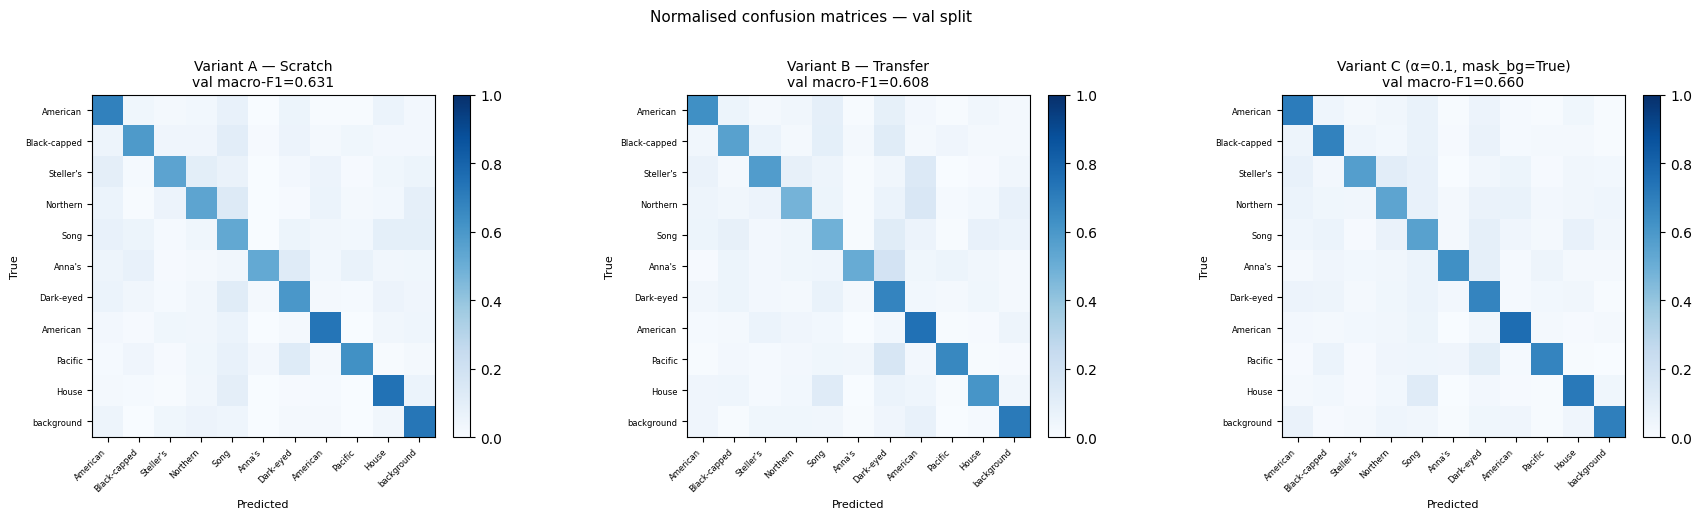

Saved /Users/aaravwadhwani/Desktop/EE446/Final Project/PocketBirdNET/data/confusion_train_variants.png

Next: notebooks/04_compress_deploy.ipynb — prune + INT8 quantize variant C → D.


In [18]:
# ── Confusion matrices ────────────────────────────────────────────────────────
n_variants = len(results)
fig, axes = plt.subplots(1, n_variants, figsize=(6 * n_variants, 5))
if n_variants == 1:
    axes = [axes]

_cm_labels = {
    "A": "A — Scratch",
    "B": "B — Transfer",
    "C": results.get("C", {}).get("variant", "C — Distill"),
}
for ax, (var, r) in zip(axes, results.items()):
    label = _cm_labels.get(var, var)
    im = plot_confusion_matrix(y_val, r["preds"],
                               title=f"Variant {label}\nval macro-F1={r['macro_f1']:.3f}",
                               ax=ax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Normalised confusion matrices — val split", y=1.02, fontsize=11)
plt.tight_layout()

fig_path = DATA_DIR / "confusion_train_variants.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved {fig_path}")

print()
print("Next: notebooks/04_compress_deploy.ipynb — prune + INT8 quantize variant C → D.")